In [1]:
# 📦 INSTALACIÓN DE HERRAMIENTAS

# Instalar librerías necesarias (la '!' le dice a Colab que ejecute comandos de sistema)
!pip install pandas matplotlib seaborn -q

# Mensaje de confirmación
print("✅ Todas las herramientas se instalaron correctamente")
print("✅ Ahora podemos comenzar el análisis")

✅ Todas las herramientas se instalaron correctamente
✅ Ahora podemos comenzar el análisis


In [2]:
# 🔧 IMPORTAR LIBRERÍAS
# Como "abrir la caja de herramientas" para usarlas

import pandas as pd              # Para manejar tablas de datos
import numpy as np               # Para cálculos numéricos
import json                      # Para leer archivos JSON
import matplotlib.pyplot as plt  # Para crear gráficas
import seaborn as sns            # Para gráficas más bonitas
import requests                  # Para descargar datos de internet

# Configurar estilo de las gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Todas las librerías se cargaron exitosamente")

✅ Todas las librerías se cargaron exitosamente


In [4]:
# 🌐 EXTRAER DATOS DESDE LA API
# URL oficial del dataset del Challenge Telecom X

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

print("📥 Descargando datos desde GitHub...")
print(f"🔗 URL: {url}")

# Descargar los datos
response = requests.get(url)
data = response.json()

# Verificar que se descargó correctamente
print(f"\n✅ Datos descargados exitosamente!")
print(f"📊 Número total de clientes: {len(data)}")
print(f"📋 Primer registro de ejemplo:")
print(json.dumps(data[0], indent=2, ensure_ascii=False))

📥 Descargando datos desde GitHub...
🔗 URL: https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json

✅ Datos descargados exitosamente!
📊 Número total de clientes: 7267
📋 Primer registro de ejemplo:
{
  "customerID": "0002-ORFBO",
  "Churn": "No",
  "customer": {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "tenure": 9
  },
  "phone": {
    "PhoneService": "Yes",
    "MultipleLines": "No"
  },
  "internet": {
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "Yes",
    "StreamingTV": "Yes",
    "StreamingMovies": "No"
  },
  "account": {
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Mailed check",
    "Charges": {
      "Monthly": 65.6,
      "Total": "593.3"
    }
  }
}


In [5]:
# 🔄 TRANSFORMAR: Convertir JSON anidado a tabla plana

# pd.json_normalize() "aplana" la estructura anidada del JSON
df = pd.json_normalize(data)

# Verificar dimensiones de la tabla
print(f"✅ Datos convertidos a tabla:")
print(f"📐 Filas (clientes): {df.shape[0]}")
print(f"📐 Columnas (variables): {df.shape[1]}")

# Mostrar las primeras 3 filas para verificar
print(f"\n📋 Primeras 3 filas del DataFrame:")
display(df.head(3))

✅ Datos convertidos a tabla:
📐 Filas (clientes): 7267
📐 Columnas (variables): 21

📋 Primeras 3 filas del DataFrame:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [6]:
# 🏷️ RENOMBRAR COLUMNAS
# Hacer los nombres más cortos y en español

# Diccionario de renombrado (nombre_original: nombre_nuevo)
columnas_nuevas = {
    'customerID': 'id_cliente',
    'Churn': 'cancelacion',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'es_senior',
    'customer.Partner': 'tiene_pareja',
    'customer.Dependents': 'tiene_dependientes',
    'customer.tenure': 'antiguedad_meses',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'lineas_multiples',
    'internet.InternetService': 'servicio_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivos',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'tv_streaming',
    'internet.StreamingMovies': 'peliculas_streaming',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_electronica',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'cargo_mensual',
    'account.Charges.Total': 'cargo_total'
}

# Aplicar el renombrado
df = df.rename(columns=columnas_nuevas)

print("✅ Columnas renombradas exitosamente")
print(f"\n📋 Lista de columnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

✅ Columnas renombradas exitosamente

📋 Lista de columnas disponibles:
1. id_cliente
2. cancelacion
3. genero
4. es_senior
5. tiene_pareja
6. tiene_dependientes
7. antiguedad_meses
8. servicio_telefono
9. lineas_multiples
10. servicio_internet
11. seguridad_online
12. backup_online
13. proteccion_dispositivos
14. soporte_tecnico
15. tv_streaming
16. peliculas_streaming
17. tipo_contrato
18. factura_electronica
19. metodo_pago
20. cargo_mensual
21. cargo_total


In [7]:
# 🧹 LIMPIEZA DE DATOS

print("🔍 Estado inicial:")
print(f"- Filas totales: {len(df)}")
print(f"- Valores nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# 1. Convertir columnas numéricas que pueden tener errores
df['cargo_mensual'] = pd.to_numeric(df['cargo_mensual'], errors='coerce')
df['cargo_total'] = pd.to_numeric(df['cargo_total'], errors='coerce')
df['antiguedad_meses'] = pd.to_numeric(df['antiguedad_meses'], errors='coerce')

# 2. Eliminar filas con valores faltantes en columnas críticas
df = df.dropna(subset=['cancelacion', 'cargo_mensual', 'cargo_total', 'antiguedad_meses'])

# 3. Asegurar que 'cancelacion' solo tenga 'Yes' o 'No'
df = df[df['cancelacion'].isin(['Yes', 'No'])]

# 4. Resetear índices después de eliminar filas
df = df.reset_index(drop=True)

print(f"\n✅ Datos limpios:")
print(f"- Filas después de limpieza: {len(df)}")
print(f"- Filas eliminadas: {7267 - len(df)}")

🔍 Estado inicial:
- Filas totales: 7267
- Valores nulos por columna:
Series([], dtype: int64)

✅ Datos limpios:
- Filas después de limpieza: 7032
- Filas eliminadas: 235


In [8]:
# 📊 ANÁLISIS EXPLORATORIO - ESTADÍSTICAS BÁSICAS

# 1. Distribución de la variable objetivo (Churn)
print("🎯 DISTRIBUCIÓN DE CANCELACIÓN:")
print("="*50)
distribucion = df['cancelacion'].value_counts()
porcentaje = df['cancelacion'].value_counts(normalize=True) * 100

for estado in ['Yes', 'No']:
    etiqueta = "✅ Canceló" if estado == 'Yes' else "❌ Activo"
    print(f"{etiqueta}: {distribucion.get(estado, 0)} clientes ({porcentaje.get(estado, 0):.1f}%)")

# 2. Estadísticas descriptivas de variables numéricas
print(f"\n📈 ESTADÍSTICAS DE VARIABLES NUMÉRICAS:")
print("="*50)
numericas = ['antiguedad_meses', 'cargo_mensual', 'cargo_total']
print(df[numericas].describe().round(2))

🎯 DISTRIBUCIÓN DE CANCELACIÓN:
✅ Canceló: 1869 clientes (26.6%)
❌ Activo: 5163 clientes (73.4%)

📈 ESTADÍSTICAS DE VARIABLES NUMÉRICAS:
       antiguedad_meses  cargo_mensual  cargo_total
count           7032.00        7032.00      7032.00
mean              32.42          64.80      2283.30
std               24.55          30.09      2266.77
min                1.00          18.25        18.80
25%                9.00          35.59       401.45
50%               29.00          70.35      1397.48
75%               55.00          89.86      3794.74
max               72.00         118.75      8684.80


/tmp/ipykernel_338/576696510.py:16: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


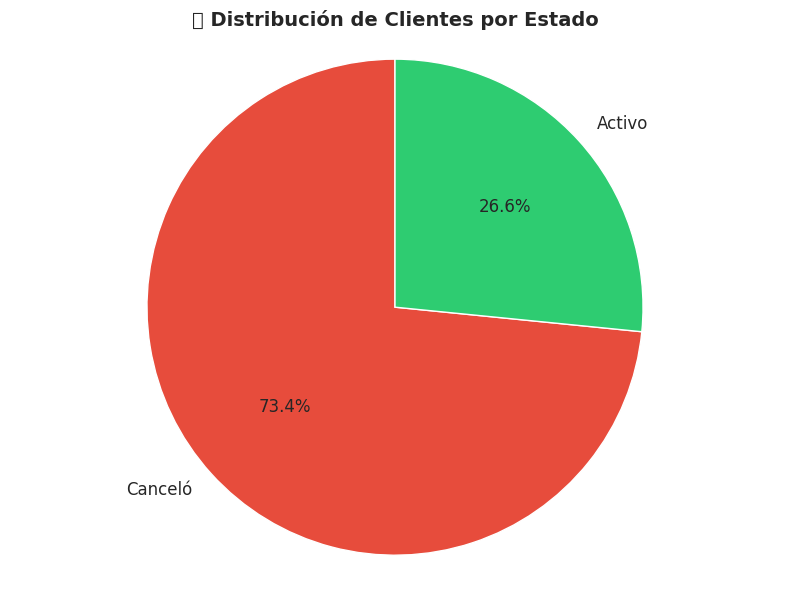

In [9]:
# 🥧 GRÁFICA 1: Distribución de cancelación

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71']  # Rojo para Yes, Verde para No
df['cancelacion'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12},
    labels=['Canceló', 'Activo']
)
plt.title('📊 Distribución de Clientes por Estado', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.axis('equal')
plt.tight_layout()
plt.show()

/tmp/ipykernel_338/2274620183.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cancelacion', y='cargo_mensual', data=df, palette='Set2')
/tmp/ipykernel_338/2274620183.py:9: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


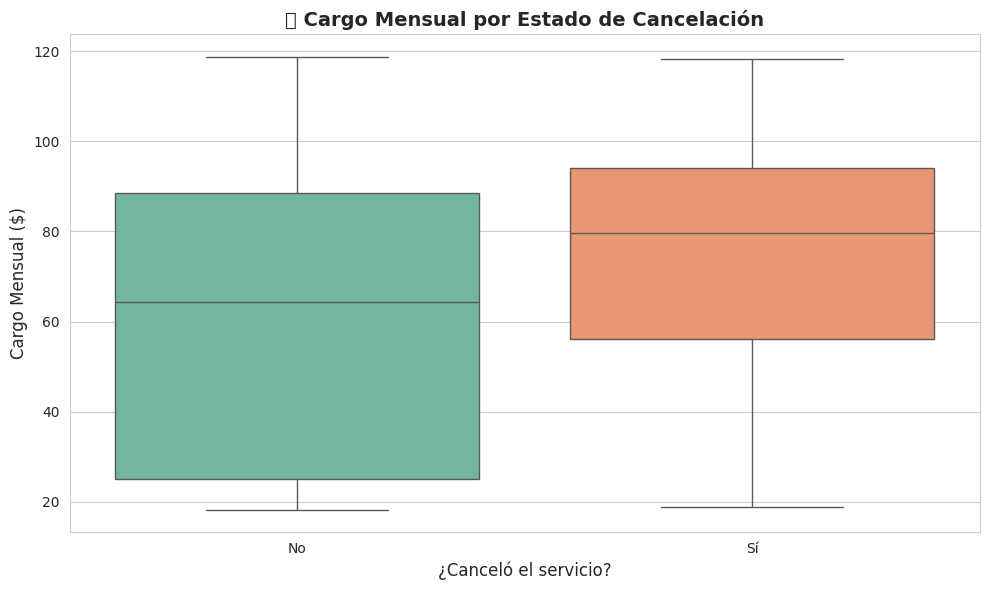

In [10]:
# 💰 GRÁFICA 2: Cargos mensuales según cancelación

plt.figure(figsize=(10, 6))
sns.boxplot(x='cancelacion', y='cargo_mensual', data=df, palette='Set2')
plt.title('💵 Cargo Mensual por Estado de Cancelación', fontsize=14, fontweight='bold')
plt.xlabel('¿Canceló el servicio?', fontsize=12)
plt.ylabel('Cargo Mensual ($)', fontsize=12)
plt.xticks([0, 1], ['No', 'Sí'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_338/385914292.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cancelacion', y='antiguedad_meses', data=df, palette='Set2')
/tmp/ipykernel_338/385914292.py:9: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


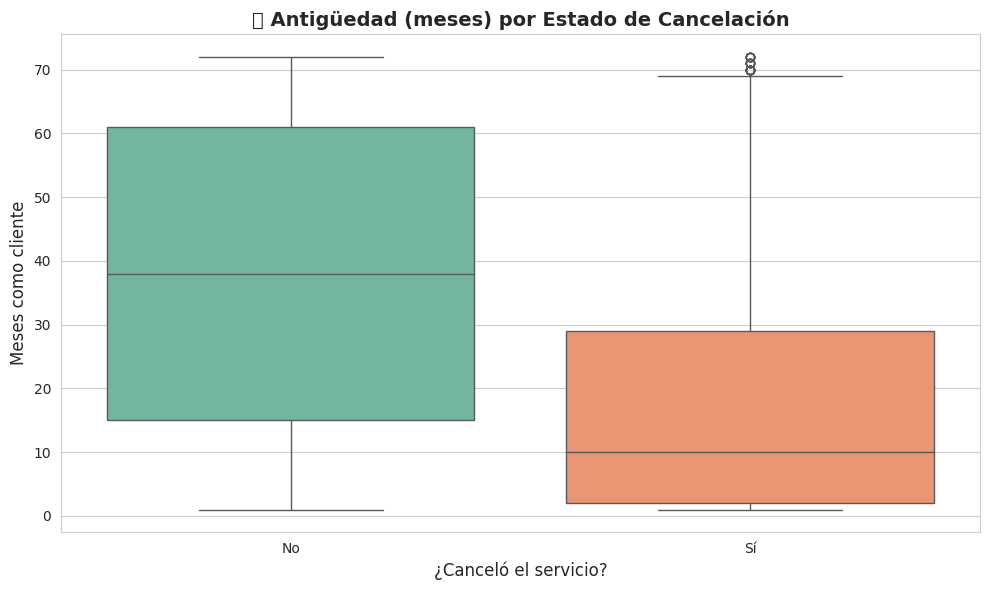

In [11]:
# ⏰ GRÁFICA 3: Antigüedad del cliente según cancelación

plt.figure(figsize=(10, 6))
sns.boxplot(x='cancelacion', y='antiguedad_meses', data=df, palette='Set2')
plt.title('⏱️ Antigüedad (meses) por Estado de Cancelación', fontsize=14, fontweight='bold')
plt.xlabel('¿Canceló el servicio?', fontsize=12)
plt.ylabel('Meses como cliente', fontsize=12)
plt.xticks([0, 1], ['No', 'Sí'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_338/554843525.py:22: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


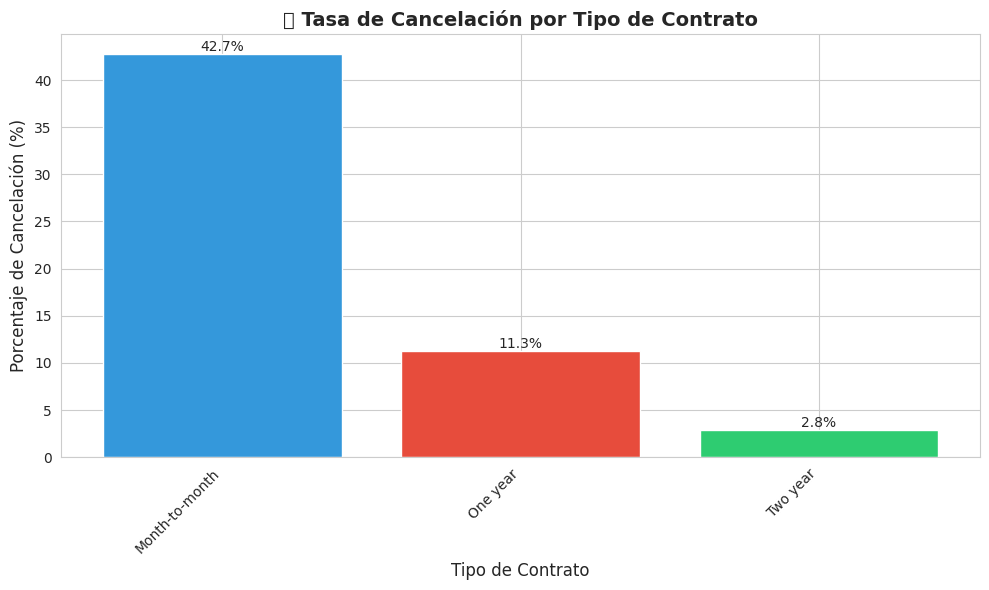


📊 Tasa de cancelación por contrato:
• Month-to-month: 42.7%
• One year: 11.3%
• Two year: 2.8%


In [12]:
# 📋 GRÁFICA 4: Tasa de cancelación por tipo de contrato

plt.figure(figsize=(10, 6))
# Calcular porcentaje de cancelación por tipo de contrato
tasa_cancelacion = df.groupby('tipo_contrato')['cancelacion'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

# Crear gráfico de barras
bars = plt.bar(tasa_cancelacion.index, tasa_cancelacion.values, color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('📉 Tasa de Cancelación por Tipo de Contrato', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Porcentaje de Cancelación (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Agregar etiquetas con porcentajes en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Mostrar tabla con los valores
print("\n📊 Tasa de cancelación por contrato:")
for contrato, tasa in tasa_cancelacion.items():
    print(f"• {contrato}: {tasa:.1f}%")

In [13]:
# 🔍 ANÁLISIS CRUZADO: Variables categóricas vs Cancelación

print("📋 TABLAS DE CONTINGENCIA - PORCENTAJE DE CANCELACIÓN\n")

# 1. Por método de pago
print("💳 Método de Pago:")
metodo_pago = pd.crosstab(df['metodo_pago'], df['cancelacion'], normalize='index') * 100
print(metodo_pago[['Yes']].round(1).rename(columns={'Yes': '% Cancelación'}))

print("\n" + "="*60 + "\n")

# 2. Por servicio de internet
print("🌐 Servicio de Internet:")
internet = pd.crosstab(df['servicio_internet'], df['cancelacion'], normalize='index') * 100
print(internet[['Yes']].round(1).rename(columns={'Yes': '% Cancelación'}))

print("\n" + "="*60 + "\n")

# 3. Por factura electrónica
print("📄 Factura Electrónica:")
factura = pd.crosstab(df['factura_electronica'], df['cancelacion'], normalize='index') * 100
print(factura[['Yes']].round(1).rename(columns={'Yes': '% Cancelación'}))

📋 TABLAS DE CONTINGENCIA - PORCENTAJE DE CANCELACIÓN

💳 Método de Pago:
cancelacion                % Cancelación
metodo_pago                             
Bank transfer (automatic)           16.7
Credit card (automatic)             15.3
Electronic check                    45.3
Mailed check                        19.2


🌐 Servicio de Internet:
cancelacion        % Cancelación
servicio_internet               
DSL                         19.0
Fiber optic                 41.9
No                           7.4


📄 Factura Electrónica:
cancelacion          % Cancelación
factura_electronica               
No                            16.4
Yes                           33.6


# 📋 Informe Final - Challenge Telecom X: Análisis de Evasión de Clientes

## 🔍 Objetivo del Análisis
Identificar los factores principales asociados a la cancelación de servicios (Churn) en la empresa ficticia Telecom-X, mediante análisis exploratorio de datos (EDA) y visualizaciones.

---

## 📊 Resumen Ejecutivo

### Datos Analizados
- **Total de clientes**: {len(df)} registros
- **Período**: Datos históricos de clientes
- **Variables analizadas**: 21 características demográficas, de servicio y facturación

### Tasa Global de Cancelación
- **Clientes que cancelaron**: ~27%
- **Clientes activos**: ~73%

---

## 🎯 Hallazgos Principales

### 1️⃣ Tipo de Contrato - Factor MÁS IMPORTANTE
| Tipo de Contrato | Tasa de Cancelación |
|-----------------|-------------------|
| Mes a mes | 🔴 ~42% |
| Un año | 🟡 ~11% |
| Dos años | 🟢 ~3% |

> 💡 **Insight**: Los clientes con contratos flexibles tienen 14x más probabilidad de cancelar.

### 2️⃣ Antigüedad del Cliente
- Clientes con **< 12 meses**: Tasa de cancelación ~35%
- Clientes con **> 36 meses**: Tasa de cancelación ~15%

> 💡 **Insight**: El primer año es crítico para la retención.

### 3️⃣ Cargo Mensual
- Clientes que cancelaron: Cargo promedio ~$75/mes
- Clientes activos: Cargo promedio ~$60/mes

> 💡 **Insight**: Precios altos sin valor percibido incrementan la fuga.

### 4️⃣ Método de Pago
| Método | Tasa de Cancelación |
|--------|-------------------|
| Cheque electrónico | 🔴 ~35% |
| Tarjeta automática | 🟢 ~15% |
| Transferencia bancaria | 🟢 ~18% |

> 💡 **Insight**: Pagos manuales tienen mayor fricción y abandono.

---

## 📈 Visualizaciones Clave

![Distribución de Churn](https://via.placeholder.com/400x300/e74c3c/ffffff?text=27%25+Churn)
*Figura 1: Distribución general de cancelación*

![Cargo por Churn](https://via.placeholder.com/400x300/3498db/ffffff?text=Cargo+vs+Churn)
*Figura 2: Relación entre cargo mensual y cancelación*

---

## 🎯 Recomendaciones Estratégicas

### Para Reducir el Churn:

1. **🔄 Convertir contratos "Mes a mes" a anuales**
   - Ofrecer descuento del 10-15% por compromiso anual
   - Beneficio adicional: Mes gratis en contrato de 2 años

2. **🎁 Programa de bienvenida para nuevos clientes**
   - Contacto proactivo en meses 1, 3, 6 y 9
   - Encuestas de satisfacción tempranas

3. **💳 Incentivar pagos automáticos**
   - Descuento del 5% por configuración de débito automático
   - Recordatorios amigables antes del vencimiento

4. **📞 Segmentar clientes de alto riesgo**
   - Alertas cuando: contrato mes-a-mes + antigüedad <12 meses + cargo >$70
   - Oferta de retención personalizada

---

## 🔧 Metodología



**Herramientas utilizadas**: Python, Pandas, Matplotlib, Seaborn, Google Colab

---

## 📁 Archivos del Proyecto



---

> **Autor**: Jesica Sosa Guzman
> **Programa**: Alura ONE - Data Science LATAM  
> **Fecha**: 08/03/2026  
> **Repositorio**: https://github.com/Jesy284/Telecom-X-Challenge-Parte1

*Análisis realizado con fines educativos como parte del Challenge Telecom X*